In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time

import networkx as nx

from coppeliasim_zmqremoteapi_client import RemoteAPIClient 

def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])

## Análise de mapa

In [ ]:
def mapa(image_caminho,start_node,end_node,escala_imagem,tamanho_cell):

    fig = plt.figure(figsize=(8,8), dpi=100)
    ax = fig.add_subplot(111, aspect='equal')

    # Invertendo os valores para visualizacao (Branco - 0, Preto - 1)

    img = mpimg.imread(image_caminho).astype(float)

    if img.ndim == 3:
        img = img[:, :, 0]

    img = 1 - img

    # Apenas para garantir que so teremos esses dois valores
    threshold = 0.5
    img[img > threshold] = 1
    img[img<= threshold] = 0

    # Dimensoes do mapa informado em metros (X, Y)
    map_dims = np.array(escala_imagem)

    # Escala Pixel/Metro
    sy, sx = img.shape[:2] / map_dims

    # Tamanho da celula do nosso Grid (em metros)
    cell_size = tamanho_cell

    rows, cols = (map_dims / cell_size).astype(int)
    grid = np.zeros((rows, cols))

    # Preenchendo o Grid
    # Cada celula recebe o somatorio dos valores dos Pixels
    for r in range(rows):
        for c in range(cols):
            
            xi = int(c*cell_size*sx)
            xf = int(xi + cell_size*sx)
            
            yi = int(r*cell_size*sy)
            yf = int(yi + cell_size*sy)
                        
            grid[r, c] = np.sum(img[yi:yf,xi:xf])
            
    # Binarizando as celulas como ocupadas (1) ou Nao-ocupadas (0)       
    grid[grid > threshold] = 1
    grid[grid<= threshold] = 0   

    # Criando o Grafo para o Grid

    # Criando vertices em todas as celulas
    G = nx.grid_2d_graph(rows, cols) 
    G_complete = G.copy()

    # Removendo celulas que estão em celulas marcas com obstáculos
    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == 1:  
                G.remove_node((r,c))

    # Os vertices serao plotados no centro da celula  
    pos = {node:(node[1]*cell_size+cell_size/2, map_dims[0]-node[0]*cell_size-cell_size/2) for node in G.nodes()}

    # Mapa
    obj = ax.imshow(grid, cmap='Greys', extent=(0, map_dims[1], 0,map_dims[0]))

    # Caminho
    path = nx.shortest_path(G, source=start_node, target=end_node)
    nx.draw_networkx_nodes(G, pos, nodelist=path, node_size=100, node_color='b')

    return pos, path,G


## Controle do robô

In [ ]:
# (79,80) , (13,29)
# (42,20) ,(13,25)
# (14,18) ,(68,63)
# (72,87) ,(12,87)
# (81,36) ,(89,78)

# (90,89) ,(90,45)
# (28,36) ,(10,13)
# (11,8)  ,(32,41)
# (32,65) ,(67,74)
# (7,14)  ,(54,89)



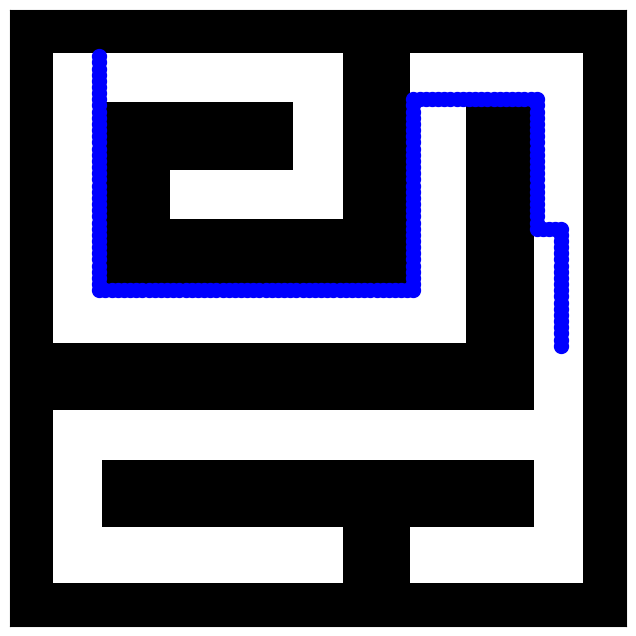

In [56]:
pos, path,G = mapa('../mapas_meus/mapa2_invertido_extend.png',(7,14)  ,(54,89),(100,100),(1))

In [13]:
def pixel_to_world(x_px, y_px, img_size, world_size):
    scale = world_size / img_size  # m/pixel
    x_world = (x_px + 0.1  - img_size/2) * scale
    y_world = (y_px + 0.1 - img_size/2) * scale 
    return x_world, y_world



In [57]:
# Informacao do robotino
L = 0.135  # distancia do centro as rodas (m)
r = 0.040  # raio das rodas (m)


pos_world = {node: pixel_to_world(x_px, y_px, 100, 10) for node, (x_px, y_px) in pos.items()}

Mdir = np.array([[-r/np.sqrt(3),     0,        r/np.sqrt(3)], 
                 [r/3,            (-2*r)/3,    r/3], 
                 [r/(3*L),         r/(3*L),    r/(3*L)]])


# Posicao inicial do robo - o mesmo da caminho
start_node = path[0]
start_pos_world = pos_world[start_node]
start_pos_sim = [start_pos_world[0], start_pos_world[1], 0.08]
start_ori_sim = [0, 0, np.deg2rad(90)]


# Conexao Coppelia
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)

robotname = 'robotino'
robotHandle = sim.getObject(f'/{robotname}')

wheel1 = sim.getObject(f'/{robotname}/wheel0_joint')
wheel2 = sim.getObject(f'/{robotname}/wheel1_joint')
wheel3 = sim.getObject(f'/{robotname}/wheel2_joint')


# Parar a simulacao se estiver executando
initial_sim_state = sim.getSimulationState()
if initial_sim_state != 0:
    sim.stopSimulation()
    time.sleep(1)

sim.startSimulation()
sim.setObjectPosition(robotHandle, sim.handle_world, start_pos_sim)
sim.setObjectOrientation(robotHandle, sim.handle_world, start_ori_sim)
sim.step()

# Estado inicial
q = np.array([start_pos_sim[0], start_pos_sim[1], start_ori_sim[2]])

print("Iniciando o caminho")

# Caminhos a ser seguidos
waypoints = [pos_world[node] for node in path]
target_index = 0
tolerance = 0.2

while target_index < len(waypoints):

    dt = sim.getSimulationTimeStep()
    target = np.array(waypoints[target_index])
    pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
    q[:2] = pos_sim[:2]

    # Erro no referencial do mundo
    erro = target - q[:2]
    dist = np.linalg.norm(erro)

    # Controlador proporcional
    vx_world = 0.5 * erro[0]
    vy_world = 0.5 * erro[1]

    # Limita velocidades
    vx_world = np.clip(vx_world, -0.3, 0.3)
    vy_world = np.clip(vy_world, -0.3, 0.3)

    # Converte velocidade do mundo 
    v_body = Rz(-start_ori_sim[2]) @ np.array([vx_world, vy_world, 0.04])


    # vz_body e descartado por ser 0
    vx_body, vy_body , vz_body = v_body
    w = 0.0  # sem rotação

    # Calcula velocidades das rodas
    qdot = np.array([vx_body, vy_body, w])

    Minv = np.linalg.pinv(Mdir)
    u = Minv @ qdot  # usa cinematica inversa para gerar rodas

    # Envia velocidades
    sim.setJointTargetVelocity(wheel1, u[0])
    sim.setJointTargetVelocity(wheel2, u[1])
    sim.setJointTargetVelocity(wheel3, u[2])

    v = Mdir @ u
    q[0] += v[0] * dt
    q[1] += v[1] * dt
    q[2] += v[2] * dt

    # Avança um passo
    sim.step()

    # Verifica se chegou
    if dist < tolerance:
        print(f"Chegou em {path[target_index]} -> indo para o proximo ponto")
        target_index += 1


print("Caminho concluido! Parando robo...")
for w in [wheel1, wheel2, wheel3]:
    sim.setJointTargetVelocity(w, 0)

pos_final = sim.getObjectPosition(robotHandle, sim.handle_world)
print("Posicao final (SIM):", pos_final)
sim.stopSimulation()
print("Programa finalizado.")


Iniciando o caminho
Chegou em (7, 14) -> indo para o proximo ponto
Chegou em (8, 14) -> indo para o proximo ponto
Chegou em (9, 14) -> indo para o proximo ponto
Chegou em (10, 14) -> indo para o proximo ponto
Chegou em (11, 14) -> indo para o proximo ponto
Chegou em (12, 14) -> indo para o proximo ponto
Chegou em (13, 14) -> indo para o proximo ponto
Chegou em (14, 14) -> indo para o proximo ponto
Chegou em (15, 14) -> indo para o proximo ponto
Chegou em (16, 14) -> indo para o proximo ponto
Chegou em (17, 14) -> indo para o proximo ponto
Chegou em (18, 14) -> indo para o proximo ponto
Chegou em (19, 14) -> indo para o proximo ponto
Chegou em (20, 14) -> indo para o proximo ponto
Chegou em (21, 14) -> indo para o proximo ponto
Chegou em (22, 14) -> indo para o proximo ponto
Chegou em (23, 14) -> indo para o proximo ponto
Chegou em (24, 14) -> indo para o proximo ponto
Chegou em (25, 14) -> indo para o proximo ponto
Chegou em (26, 14) -> indo para o proximo ponto
Chegou em (27, 14) -> i